# Итоговая контрольная работа по ИКНТ  
## Анализ и прогнозирование многомерного временного ряда `mpi_roof.csv`

**Цель работы:** построить полный pipeline прогнозирования температуры воздуха `T (degC)` на **24 часа вперёд** по многомерному временному ряду метеорологических измерений.

### Постановка задачи
В каждый момент времени наблюдаются температура, давление, влажность, ветер, осадки, солнечная радиация и другие признаки. Прогнозируется числовое значение температуры через сутки, следовательно, решается задача **регрессии / прогнозирования**.

### Что реализовано
1. Описание и проверка датасета.
2. EDA: временные графики, тренд, сезонность, автокорреляция и выбросы.
3. ADF-тест стационарности.
4. Предобработка: часовая агрегация, интерполяция, encoding циклических переменных и scaling.
5. Три метода извлечения признаков: **lag features**, **rolling statistics**, **FFT features**.
6. Модели: **Random Forest**, **CNN1D**, **LSTM**.
7. Сравнение по метрикам **MAE**, **RMSE**, **R²**.
8. Автоматическое формирование итогового вывода.

> Временной ряд делится хронологически: прошлое используется для обучения, будущее — для проверки. Случайное перемешивание здесь недопустимо из-за риска утечки данных.

In [2]:
import copy
import random
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from scipy import signal
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import RobustScaler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство для нейросетей:", DEVICE)

Устройство для нейросетей: cuda


## 1. Описание датасета

Столбец `Date Time` является временной осью. Целевая переменная — `T (degC)`.

Признаки датасета:

| Признак                | Описание                                        |
| ---------------------- | ----------------------------------------------- |
| `p (mbar)`             | атмосферное давление                            |
| `T (degC)`             | температура воздуха, целевая переменная         |
| `Tpot (K)`             | потенциальная температура воздуха               |
| `Tdew (degC)`          | температура точки росы                          |
| `rh (%)`               | относительная влажность воздуха                 |
| `VPmax (mbar)`         | максимальное давление водяного пара             |
| `VPact (mbar)`         | фактическое давление водяного пара              |
| `VPdef (mbar)`         | дефицит давления водяного пара                  |
| `sh (g/kg)`            | удельная влажность воздуха                      |
| `H2OC (mmol/mol)`      | концентрация водяного пара                      |
| `rho (g/m**3)`         | плотность воздуха                               |
| `wv (m/s)`             | средняя скорость ветра                          |
| `max. wv (m/s)`        | максимальная скорость ветра                     |
| `wd (deg)`             | направление ветра                               |
| `rain (mm)`            | количество осадков                              |
| `raining (s)`          | продолжительность выпадения осадков             |
| `SWDR (W/m²)`          | солнечная радиация                              |
| `PAR (µmol/m²/s)`      | фотосинтетически активная радиация              |
| `max. PAR (µmol/m²/s)` | максимальная фотосинтетически активная радиация |
| `Tlog (degC)`          | температура регистратора данных                 |


In [4]:
df = pd.read_csv('mpi_roof.csv', parse_dates=["Date Time"])
df = df.sort_values("Date Time").drop_duplicates("Date Time").reset_index(drop=True)

print("Размер исходного датасета:", df.shape)
print("Период наблюдений:", df["Date Time"].min(), "—", df["Date Time"].max())
print("Дубликатов временных меток:", df["Date Time"].duplicated().sum())
print("Всего пропусков:", int(df.isna().sum().sum()))
display(df.head())

description = pd.DataFrame({
    "Тип": df.dtypes.astype(str),
    "Пропуски": df.isna().sum(),
    "Минимум": df.select_dtypes(include="number").min(),
    "Максимум": df.select_dtypes(include="number").max(),
})
display(description)

Размер исходного датасета: (1051920, 21)
Период наблюдений: 2004-01-01 00:10:00 — 2024-01-01 00:00:00
Дубликатов временных меток: 0
Всего пропусков: 0


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),...,rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC)
0,2004-01-01 00:10:00,996.82,-0.84,272.57,-1.23,97.2,5.74,5.58,0.16,3.49,...,1272.50,2.53,3.63,26.15,0.0,0.0,0.0,0.0,0.0,8.57
1,2004-01-01 00:20:00,996.69,-0.78,272.64,-1.22,96.8,5.77,5.59,0.18,3.49,...,1272.04,2.08,3.25,29.38,0.0,0.0,0.0,0.0,0.0,9.07
2,2004-01-01 00:30:00,996.69,-0.77,272.64,-1.29,96.3,5.77,5.56,0.21,3.48,...,1272.04,2.09,3.75,19.44,0.0,0.0,0.0,0.0,0.0,9.27
3,2004-01-01 00:40:00,996.67,-0.77,272.65,-1.39,95.6,5.77,5.52,0.25,3.45,...,1272.04,1.94,3.63,19.66,0.0,0.0,0.0,0.0,0.0,8.94
4,2004-01-01 00:50:00,996.52,-0.77,272.66,-1.44,95.2,5.77,5.49,0.28,3.44,...,1271.86,1.28,2.25,21.53,0.0,0.0,0.0,0.0,0.0,8.46


,Тип,Пропуски,Минимум,Максимум
Date Time,datetime64[ns],0,NaN,NaN
H2OC (mmol/mol),float64,0,0.80,28.82
PAR (µmol/m²/s),float64,0,0.00,2401.54
SWDR (W/m²),float64,0,0.00,1219.32
T (degC),float64,0,-23.01,37.95
Tdew (degC),float64,0,-25.01,23.11
Tlog (degC),float64,0,-6.14,50.47
Tpot (K),float64,0,250.60,312.21
VPact (mbar),float64,0,0.79,28.32
VPdef (mbar),float64,0,0.00,56.72


### Первичный вывод

Файл содержит многомерный метеорологический временной ряд. В предоставленном датасете при проверке получено **1 051 920 наблюдений**, **20 числовых признаков** и временная метка. Интервал между соседними строками составляет 10 минут, период наблюдений — с начала 2004 года до начала 2024 года.

Для прогноза температуры на сутки вперёд переход к почасовым данным оправдан: он сохраняет суточную и годовую сезонность, но уменьшает объём вычислений приблизительно в шесть раз.

In [6]:
hourly = (
    df.set_index("Date Time")
      .resample("1h")
      .mean(numeric_only=True)
      .interpolate(method="time")
      .ffill()
      .bfill()
)

TARGET = "T (degC)"
HORIZON = 24

print("Размер часового ряда:", hourly.shape)
print("Период часового ряда:", hourly.index.min(), "—", hourly.index.max())
print("Пропусков после обработки:", int(hourly.isna().sum().sum()))
display(hourly.head())

Размер часового ряда: (175321, 20)
Период часового ряда: 2004-01-01 00:00:00 — 2024-01-01 00:00:00
Пропусков после обработки: 0


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg),rain (mm),raining (s),SWDR (W/m²),PAR (µmol/m²/s),max. PAR (µmol/m²/s),Tlog (degC)
Date Time,,,,,,,,,,,,,,,,,,,,
2004-01-01 00:00:00,996.678000,-0.786000,272.632000,-1.314000,96.220000,5.764000,5.548000,0.216000,3.470000,5.566000,1272.096000,1.984000,3.302000,23.232000,0.0,0.0,0.0,0.0,0.0,8.862000
2004-01-01 01:00:00,996.278333,-0.768333,272.680000,-1.665000,93.616667,5.771667,5.405000,0.371667,3.381667,5.426667,1271.568333,1.706667,2.608333,35.671667,0.0,0.0,0.0,0.0,0.0,8.761667
2004-01-01 02:00:00,996.060000,-0.773333,272.693333,-1.880000,92.150000,5.771667,5.315000,0.453333,3.328333,5.340000,1271.351667,1.873333,2.668333,26.566667,0.0,0.0,0.0,0.0,0.0,8.865000
2004-01-01 03:00:00,995.561667,-0.826667,272.680000,-1.900000,92.383333,5.746667,5.311667,0.438333,3.323333,5.335000,1270.963333,1.950000,2.896667,35.358333,0.0,0.0,0.0,0.0,0.0,8.850000
2004-01-01 04:00:00,995.018333,-1.080000,272.468333,-2.006667,93.383333,5.643333,5.271667,0.375000,3.301667,5.295000,1271.473333,2.523333,3.503333,33.005000,0.0,0.0,0.0,0.0,0.0,8.760000


## 4. Визуализация временных рядов

Для общего обзора строятся дневные средние, поскольку на графике всех почасовых значений многолетняя структура была бы плохо различима. Дополнительно выводится последний месяц в часовом масштабе.

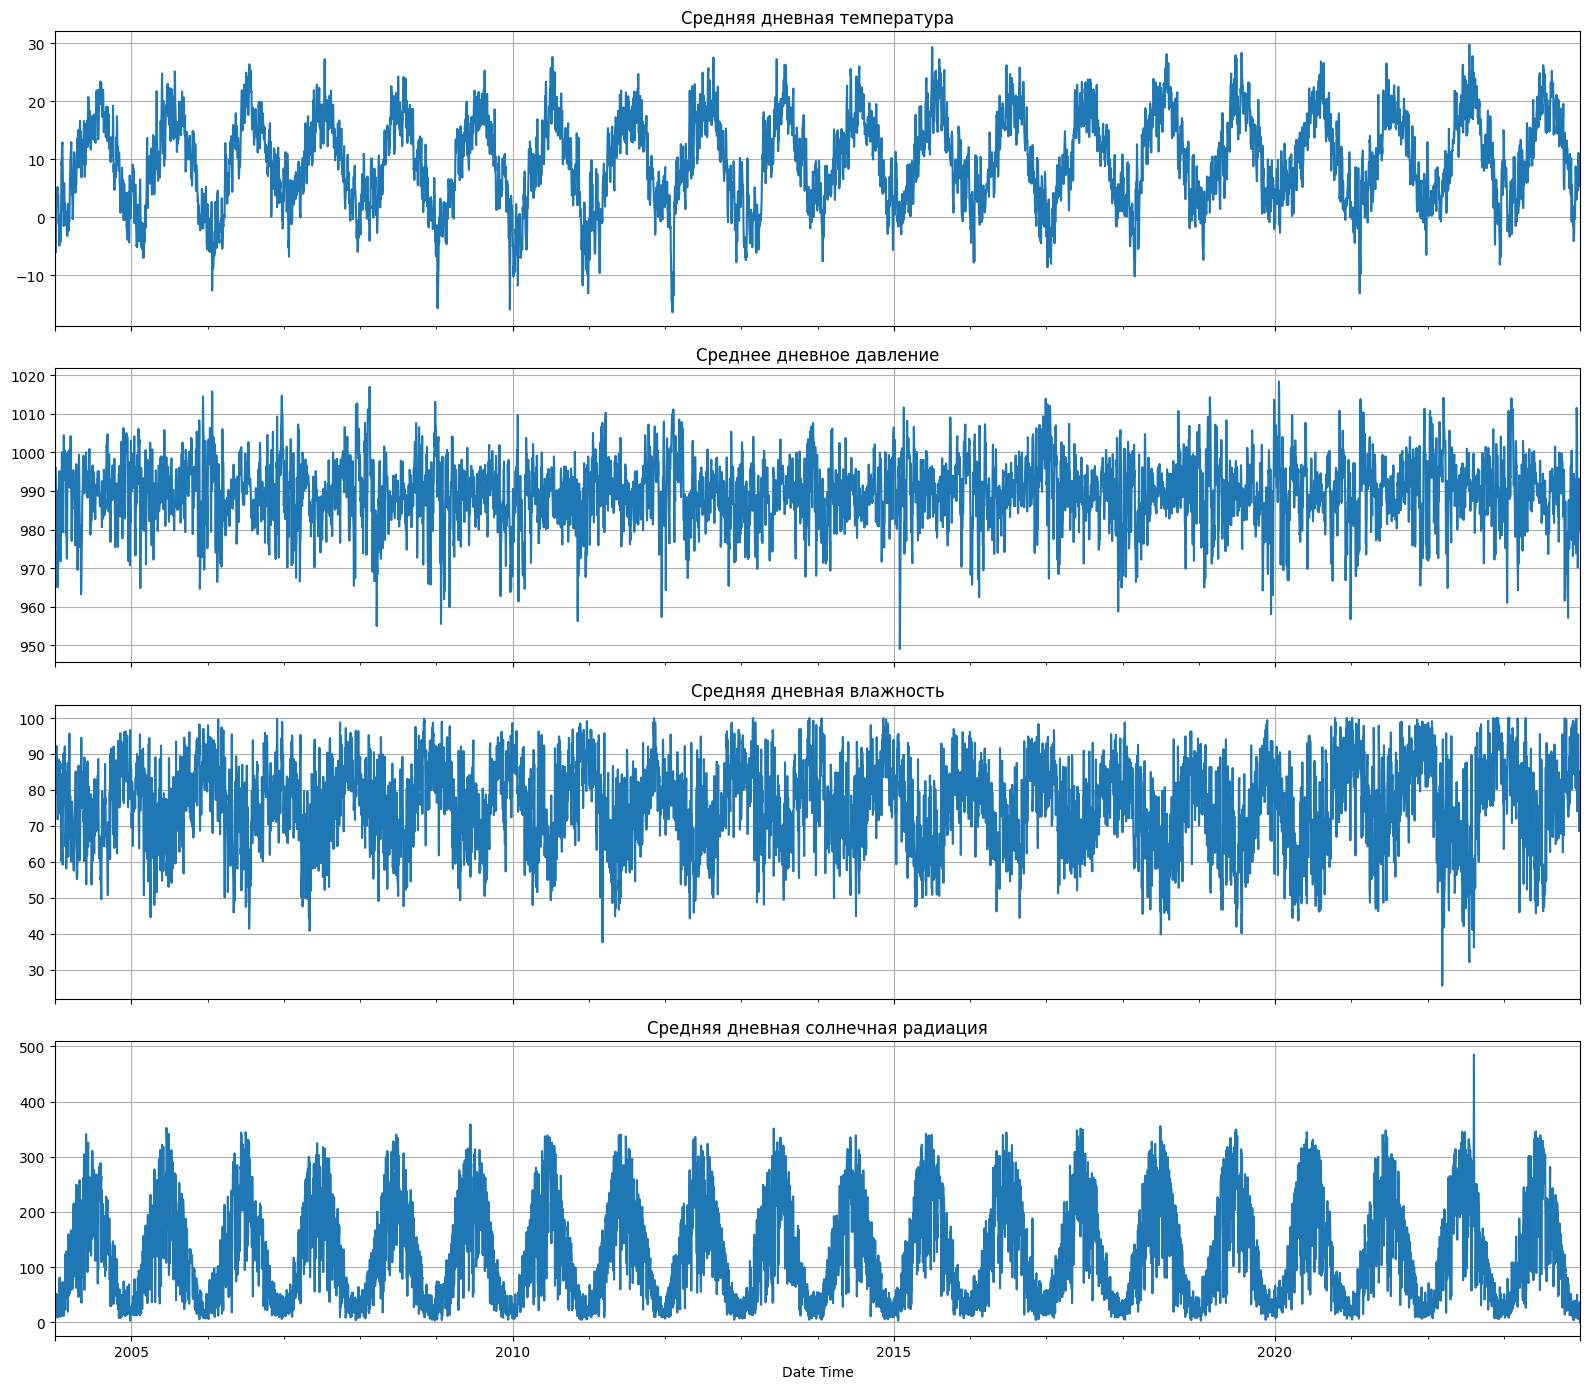

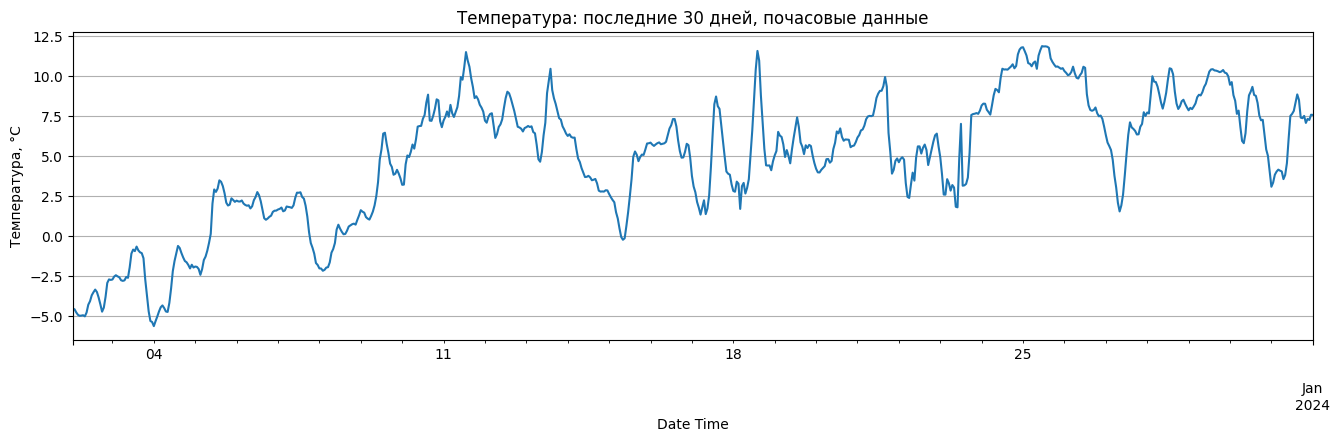

In [8]:
daily = hourly.resample("1D").mean()

fig, axes = plt.subplots(4, 1, figsize=(16, 14), sharex=True)
daily[TARGET].plot(ax=axes[0], title="Средняя дневная температура")
daily["p (mbar)"].plot(ax=axes[1], title="Среднее дневное давление")
daily["rh (%)"].plot(ax=axes[2], title="Средняя дневная влажность")
daily["SWDR (W/m²)"].plot(ax=axes[3], title="Средняя дневная солнечная радиация")
plt.tight_layout()
plt.show()

hourly[TARGET].iloc[-24 * 30:].plot(figsize=(16, 4),title="Температура: последние 30 дней, почасовые данные")
plt.ylabel("Температура, °C")
plt.show()

## 5. Тренд и сезонность

Температура обычно содержит:
- суточные колебания;
- годовую смену сезонов;
- более медленные погодные изменения.

`STL` раскладывает ряд на тренд, сезонную часть и остатки. Для демонстрации суточной сезонности используется период `24` часа.

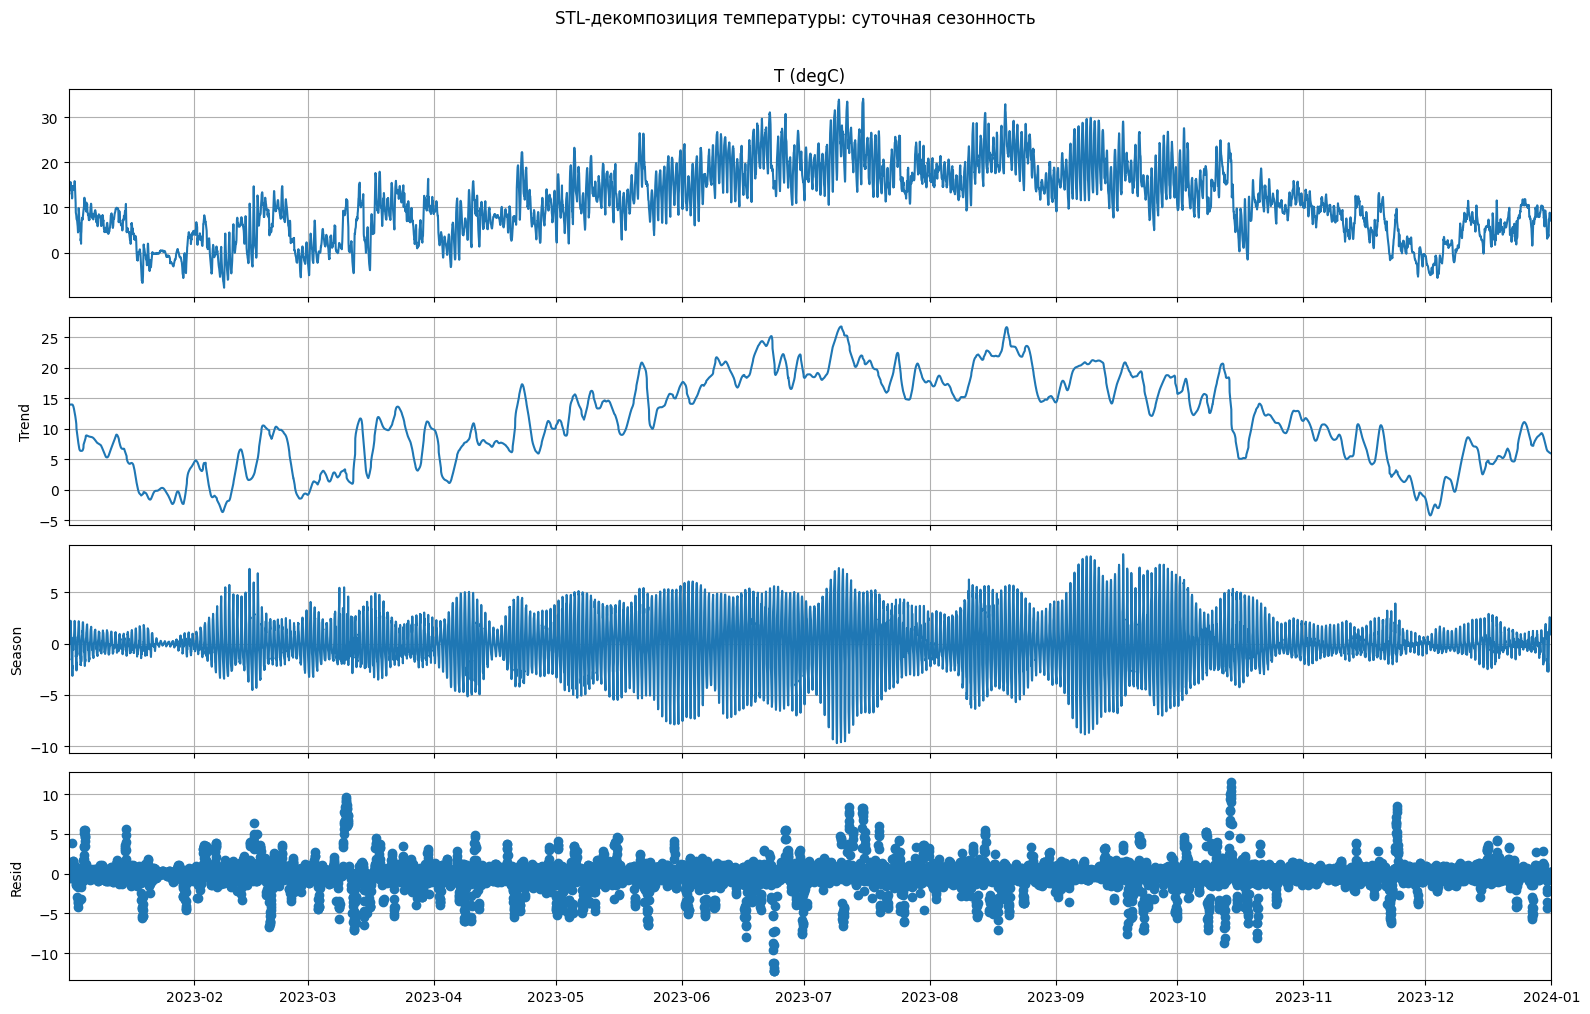

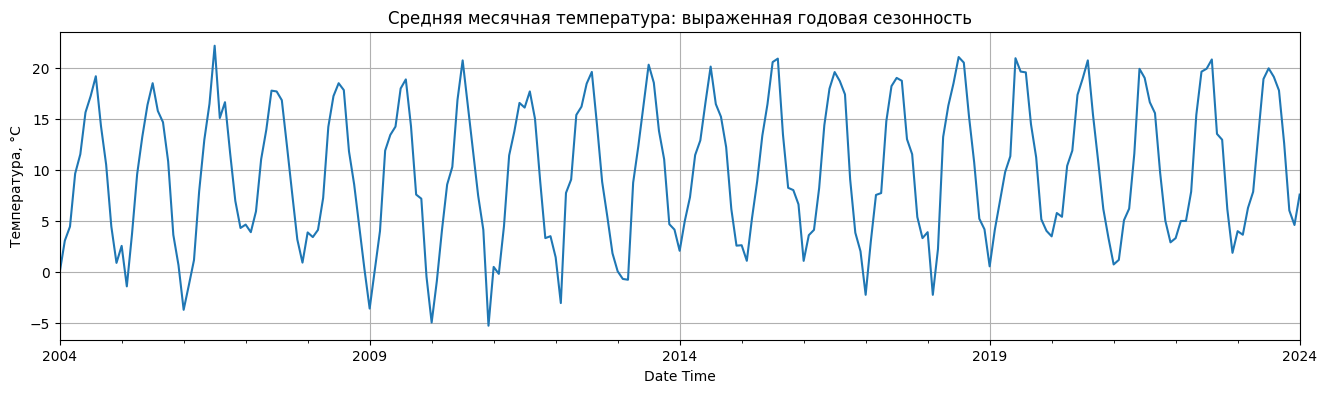

In [9]:
segment = hourly[TARGET].iloc[-24 * 365:]
stl_result = STL(segment, period=24, robust=True).fit()

fig = stl_result.plot()
fig.set_size_inches(16, 10)
plt.suptitle("STL-декомпозиция температуры: суточная сезонность", y=1.01)
plt.tight_layout()
plt.show()

hourly[TARGET].resample("MS").mean().plot(figsize=(16, 4),title="Средняя месячная температура: выраженная годовая сезонность")
plt.ylabel("Температура, °C")
plt.show()

## 6. Проверка стационарности: ADF-тест

**Стационарный ряд** имеет примерно постоянные статистические свойства во времени. Для ADF-теста:

- `H0`: ряд нестационарен;
- если `p-value < 0.05`, отвергаем `H0` и считаем ряд стационарным;
- если `p-value >= 0.05`, оснований утверждать стационарность недостаточно.

Для быстрого выполнения я использовал фрагмент последних 5000 часов.

In [11]:
def adf_report(series: pd.Series, name: str) -> dict:
    values = series.dropna().iloc[-5000:]
    statistic, p_value, used_lags, n_obs, critical_values = adfuller(
        values,
        maxlag=48,
        autolag=None
    )
    return {"Ряд": name,"ADF statistic": statistic,"p-value": p_value,"Число лагов": used_lags,"Число наблюдений": n_obs,"Стационарен при alpha=0.05": "Да" if p_value < 0.05 else "Нет"}
adf_results = pd.DataFrame([adf_report(hourly[TARGET],"Исходная температура"),adf_report(hourly[TARGET].diff(),"Первая разность температуры")])
display(
    adf_results.style.format({"ADF statistic": "{:.4f}","p-value": "{:.8f}"})
)
initial_p = adf_results.iloc[0]["p-value"]
diff_p = adf_results.iloc[1]["p-value"]
print("Интерпретация:")
if initial_p < 0.05:
    print("- Исходный температурный ряд считается стационарным.")
else:
    print("- Исходный температурный ряд нельзя считать стационарным:в нём присутствуют сезонность или изменение уровня.")
if diff_p < 0.05:
    print("- Первая разность температуры является стационарной.")
else:
    print("- Стационарность первой разности не подтверждена.")

,Ряд,ADF statistic,p-value,Число лагов,Число наблюдений,Стационарен при alpha=0.05
0,Исходная температура,-2.6191,0.08911520,48,4951,Нет
1,Первая разность температуры,-11.4382,0.00000000,48,4951,Да


Интерпретация:
- Исходный температурный ряд нельзя считать стационарным:в нём присутствуют сезонность или изменение уровня.
- Первая разность температуры является стационарной.


При проверочном запуске на предоставленном файле для исходной температуры было получено `p-value ≈ 0.089`, поэтому исходный ряд рассматривается как **нестационарный**. Для первой разности `p-value` существенно меньше 0.05. Это ожидаемо, поскольку температурный ряд содержит выраженную сезонность.Такой вывод корректен для последних 5000 часах так как его я его и использовал для быстроты вычислений.

## 7. Автокорреляция

Автокорреляция показывает, насколько текущая температура связана с прошлыми значениями. Значимая связь на лагах около 24 часов обосновывает применение суточных лагов, rolling-признаков и последовательных нейросетей.

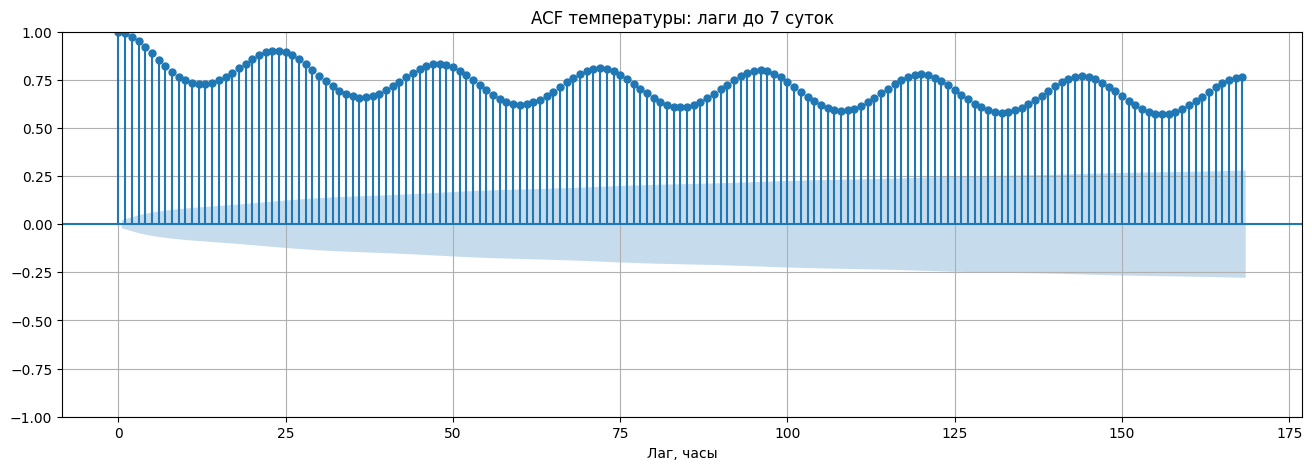

In [12]:
fig, ax = plt.subplots(figsize=(16, 5))
plot_acf(hourly[TARGET].iloc[-24 * 365:], lags=24 * 7, ax=ax)
ax.set_title("ACF температуры: лаги до 7 суток")
ax.set_xlabel("Лаг, часы")
plt.show()

## 8. Выбросы

Экстремальные погодные значения могут быть настоящими явлениями, а не ошибками измерения. Поэтому выбросы анализируются методом IQR, но автоматически не удаляются. Для нейросетей далее применяется устойчивый к выбросам `RobustScaler`.

,Признак,Количество выбросов IQR,"Доля, %",Нижняя граница,Верхняя граница
0,T (degC),372,0.21,-14.45,33.80
1,p (mbar),3405,1.94,968.20,1011.47
2,rh (%),347,0.20,26.84,126.88
3,wv (m/s),6226,3.55,-1.70,5.62
4,rain (mm),14024,8.00,0.00,0.00
5,SWDR (W/m²),18605,10.61,-263.68,439.47


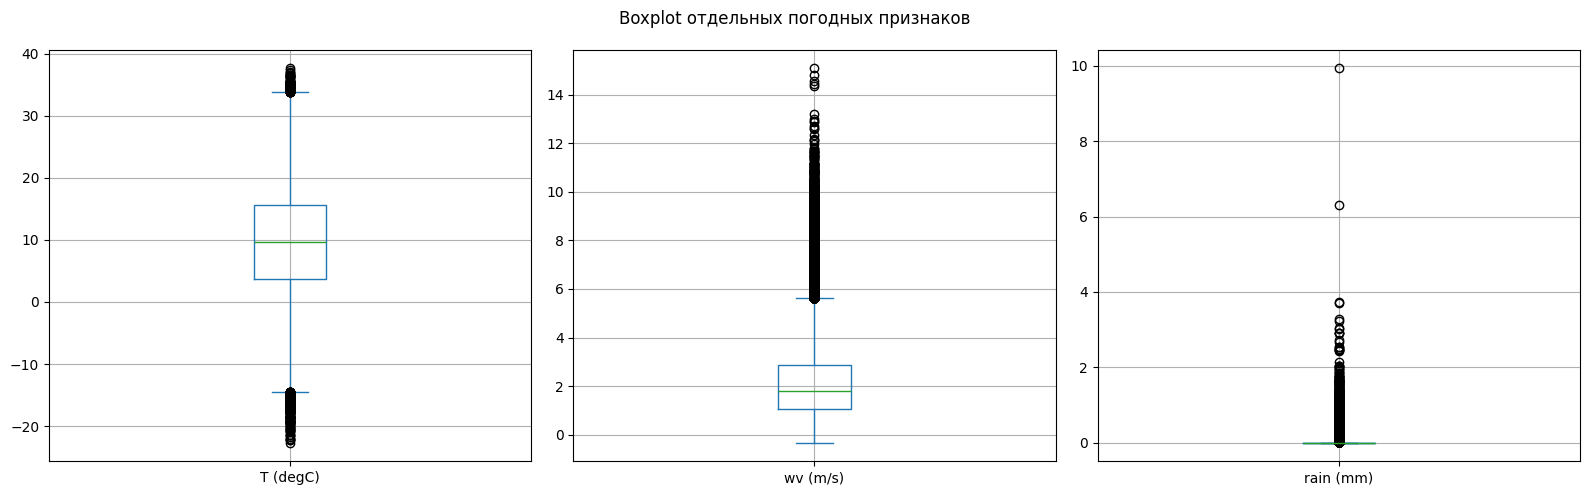

In [13]:
def iqr_outlier_count(series: pd.Series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((series < lower) | (series > upper)).sum())
    return count, lower, upper

selected = [TARGET, "p (mbar)", "rh (%)", "wv (m/s)", "rain (mm)", "SWDR (W/m²)"]
rows = []
for col in selected:
    count, lower, upper = iqr_outlier_count(hourly[col])
    rows.append({
        "Признак": col,
        "Количество выбросов IQR": count,
        "Доля, %": 100 * count / len(hourly),
        "Нижняя граница": lower,
        "Верхняя граница": upper
    })

outlier_table = pd.DataFrame(rows)
display(outlier_table.style.format({
    "Доля, %": "{:.2f}",
    "Нижняя граница": "{:.2f}",
    "Верхняя граница": "{:.2f}"
}))

hourly[[TARGET, "wv (m/s)", "rain (mm)"]].plot(
    kind="box", subplots=True, layout=(1, 3), figsize=(16, 5), sharex=False
)
plt.suptitle("Boxplot отдельных погодных признаков")
plt.tight_layout()
plt.show()

## 9. Задача прогнозирования и разбиение по времени

Прогнозируется температура через сутки:

\[
y_t = T_{t+24}
\]

Разбиение:
- первые 70% времени — `train`;
- следующие 15% — `validation`;
- последние 15% — `test`.


Конец train: 2017-12-31 12:00:00
Конец validation: 2020-12-31 06:00:00
Конец test: 2024-01-01 00:00:00


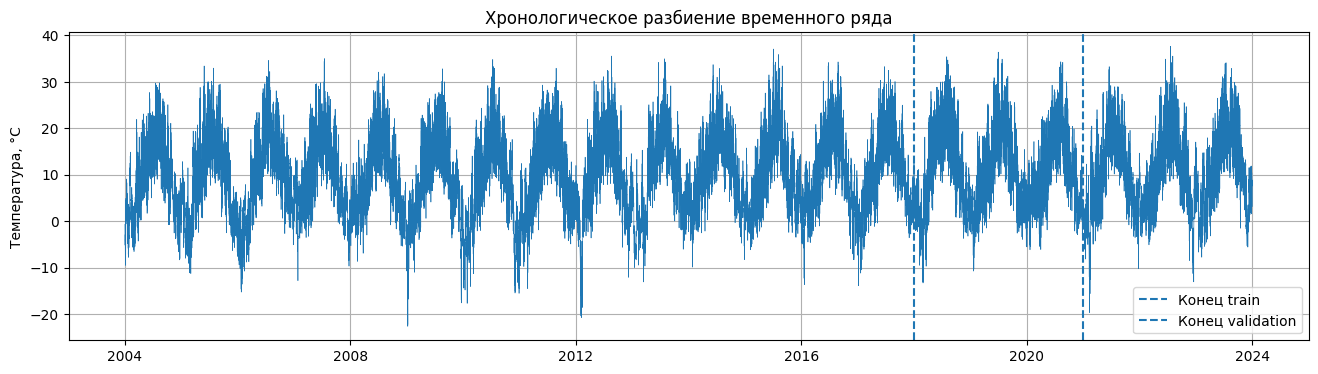

In [14]:
n = len(hourly)
train_end = hourly.index[int(n * 0.70)]
val_end = hourly.index[int(n * 0.85)]

print("Конец train:", train_end)
print("Конец validation:", val_end)
print("Конец test:", hourly.index[-1])

plt.figure(figsize=(16, 4))
plt.plot(hourly.index, hourly[TARGET], linewidth=0.45)
plt.axvline(train_end, linestyle="--", label="Конец train")
plt.axvline(val_end, linestyle="--", label="Конец validation")
plt.title("Хронологическое разбиение временного ряда")
plt.ylabel("Температура, °C")
plt.legend()
plt.show()

## 10. Feature extraction: lag, rolling statistics и FFT

### 1. Lag features
Прошлые значения целевого ряда: 1, 6, 24, 48 и 168 часов назад.

### 2. Rolling statistics
Среднее, стандартное отклонение, минимум и максимум за последние 6, 24 и 168 часов. Перед вычислением используется `shift(1)`, поэтому текущая цель и будущее не попадают в признаки.

### 3. FFT features
FFT выявляет сильные периодические компоненты обучающего ряда. На найденных периодах создаются синусные и косинусные признаки. Поиск периодов делается только на `train`, что исключает утечку.

In [15]:
def dominant_fft_periods(series: pd.Series,n_periods: int = 2,min_hours: float = 12,max_hours: float = 24 * 400,) -> list[float]:
    values = signal.detrend(series.dropna().to_numpy(dtype=float))
    frequencies = np.fft.rfftfreq(len(values), d=1.0)
    power = np.abs(np.fft.rfft(values)) ** 2

    frequencies, power = frequencies[1:], power[1:]
    periods = 1.0 / frequencies
    allowed = (periods >= min_hours) & (periods <= max_hours)
    candidates = periods[allowed][np.argsort(power[allowed])[::-1]]

    selected = []
    for period in candidates:
        if all(abs(period - saved) / saved > 0.05 for saved in selected):
            selected.append(float(period))
        if len(selected) == n_periods:
            break
    return selected

fft_periods = dominant_fft_periods(hourly.loc[:train_end, TARGET], n_periods=2)
print("Доминирующие периоды FFT, найденные только по train:")
for period in fft_periods:
    print(f"{period:.2f} часов = {period / 24:.2f} суток")

Доминирующие периоды FFT, найденные только по train:
8766.07 часов = 365.25 суток
24.00 часов = 1.00 суток


In [17]:
BASE_FEATURES = ["T (degC)", "p (mbar)", "Tdew (degC)", "rh (%)","wv (m/s)", "rain (mm)", "SWDR (W/m²)"]

feature_df = hourly[BASE_FEATURES].copy()
time_steps = np.arange(len(feature_df))
feature_df["wind_dir_sin"] = np.sin(np.deg2rad(hourly["wd (deg)"]))
feature_df["wind_dir_cos"] = np.cos(np.deg2rad(hourly["wd (deg)"]))
feature_df["hour_sin"] = np.sin(2 * np.pi * feature_df.index.hour / 24)
feature_df["hour_cos"] = np.cos(2 * np.pi * feature_df.index.hour / 24)
feature_df["year_sin"] = np.sin(2 * np.pi * feature_df.index.dayofyear / 365.25)
feature_df["year_cos"] = np.cos(2 * np.pi * feature_df.index.dayofyear / 365.25)

# Метод 1: lag features.
lag_columns = []
for lag in [1, 6, 24, 48, 168]:
    col = f"temp_lag_{lag}h"
    feature_df[col] = hourly[TARGET].shift(lag)
    lag_columns.append(col)

# Метод 2: rolling statistics только по прошлым значениям.
rolling_columns = []
past_temperature = hourly[TARGET].shift(1)
for window in [6, 24, 168]:
    statistics = {
        "mean": past_temperature.rolling(window).mean(),
        "std": past_temperature.rolling(window).std(),
        "min": past_temperature.rolling(window).min(),
        "max": past_temperature.rolling(window).max(),
    }
    for stat_name, values in statistics.items():
        col = f"temp_roll_{stat_name}_{window}h"
        feature_df[col] = values
        rolling_columns.append(col)

# Метод 3: FFT-based признаки периодов.
fft_columns = []
for number, period in enumerate(fft_periods, start=1):
    sin_col, cos_col = f"fft_sin_{number}", f"fft_cos_{number}"
    feature_df[sin_col] = np.sin(2 * np.pi * time_steps / period)
    feature_df[cos_col] = np.cos(2 * np.pi * time_steps / period)
    fft_columns += [sin_col, cos_col]


feature_df["target_future_temperature"] = hourly[TARGET].shift(-HORIZON)
feature_df["forecast_time"] = feature_df.index + pd.Timedelta(hours=HORIZON)
feature_df = feature_df.dropna()

print("Lag-признаки:", lag_columns)
print("Rolling-признаков:", len(rolling_columns))
print("FFT-признаки:", fft_columns)
print("Размер таблицы после feature extraction:", feature_df.shape)
display(feature_df.head())

Lag-признаки: ['temp_lag_1h', 'temp_lag_6h', 'temp_lag_24h', 'temp_lag_48h', 'temp_lag_168h']
Rolling-признаков: 12
FFT-признаки: ['fft_sin_1', 'fft_cos_1', 'fft_sin_2', 'fft_cos_2']
Размер таблицы после feature extraction: (175129, 36)


,T (degC),p (mbar),Tdew (degC),rh (%),wv (m/s),rain (mm),SWDR (W/m²),wind_dir_sin,wind_dir_cos,hour_sin,...,temp_roll_mean_168h,temp_roll_std_168h,temp_roll_min_168h,temp_roll_max_168h,fft_sin_1,fft_cos_1,fft_sin_2,fft_cos_2,target_future_temperature,forecast_time
Date Time,,,,,,,,,,,,,,,,,,,,,
2004-01-08 00:00:00,1.326667,991.690000,0.598333,94.883333,1.436667,0.0,0.0,-0.232314,-0.972641,0.000000,...,-2.869272,3.504617,-9.543333,4.893333,0.120125,0.992759,0.003942,0.999992,1.243333,2004-01-09 00:00:00
2004-01-08 01:00:00,1.373333,991.608333,0.695000,95.233333,1.638333,0.0,0.0,-0.186524,-0.982450,0.258819,...,-2.856696,3.515910,-9.543333,4.893333,0.120837,0.992672,0.262648,0.964892,2.925000,2004-01-09 01:00:00
2004-01-08 02:00:00,1.475000,991.546667,0.655000,94.250000,1.533333,0.0,0.0,-0.382952,-0.923768,0.500000,...,-2.843948,3.527391,-9.543333,4.893333,0.121548,0.992586,0.503451,0.864024,1.925000,2004-01-09 02:00:00
2004-01-08 03:00:00,1.421667,991.585000,0.563333,93.983333,1.185000,0.0,0.0,-0.328317,-0.944568,0.707107,...,-2.830565,3.539538,-9.543333,4.893333,0.122260,0.992498,0.709938,0.704264,0.945000,2004-01-09 03:00:00
2004-01-08 04:00:00,1.131667,991.296667,0.390000,94.783333,1.341667,0.0,0.0,-0.082808,-0.996566,0.866025,...,-2.817183,3.551391,-9.543333,4.893333,0.122971,0.992410,0.868036,0.496501,0.538333,2004-01-09 04:00:00


## 11. Классическая модель: Random Forest



Размеры выборок Random Forest: (122533, 34) (26298, 34) (26298, 34)
Время обучения Random Forest: 484.8 секунд


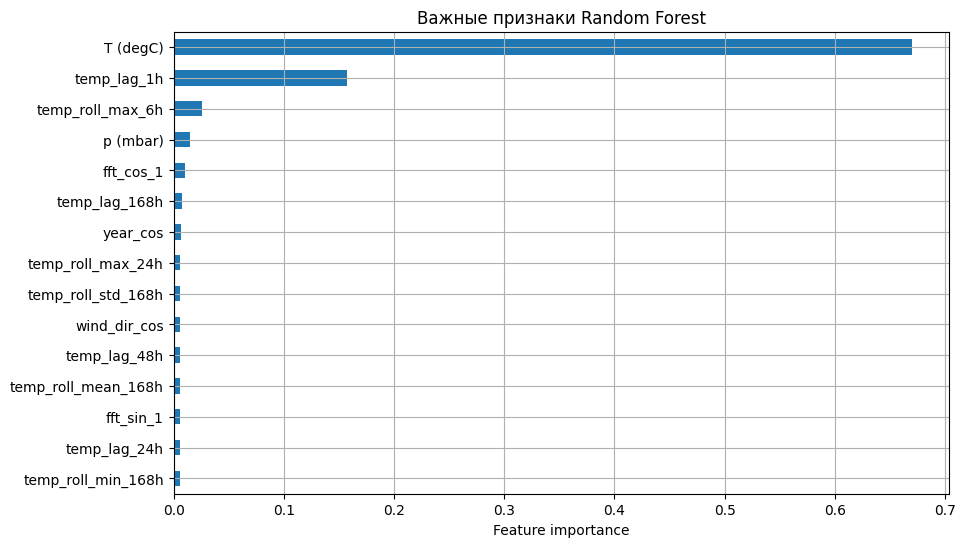

In [18]:
target_col = "target_future_temperature"
rf_features = [col for col in feature_df.columns if col not in [target_col, "forecast_time"]]

train_mask_rf = feature_df["forecast_time"] <= train_end
val_mask_rf = (feature_df["forecast_time"] > train_end) & (feature_df["forecast_time"] <= val_end)
test_mask_rf = feature_df["forecast_time"] > val_end

X_train_rf = feature_df.loc[train_mask_rf, rf_features]
y_train_rf = feature_df.loc[train_mask_rf, target_col]
X_val_rf = feature_df.loc[val_mask_rf, rf_features]
y_val_rf = feature_df.loc[val_mask_rf, target_col]
X_test_rf = feature_df.loc[test_mask_rf, rf_features]
y_test_rf = feature_df.loc[test_mask_rf, target_col]

FAST_MODE = True
rf_model = RandomForestRegressor(
    n_estimators=120 if FAST_MODE else 250,
    max_depth=22,
    min_samples_leaf=2,
    max_features=0.8,
    random_state=SEED,
    n_jobs=-1,
)

start = time.time()
rf_model.fit(pd.concat([X_train_rf, X_val_rf]), pd.concat([y_train_rf, y_val_rf]))
rf_seconds = time.time() - start

rf_predictions = rf_model.predict(X_test_rf)
rf_pred_series = pd.Series(
    rf_predictions,
    index=feature_df.loc[test_mask_rf, "forecast_time"],
    name="Random Forest"
)

print("Размеры выборок Random Forest:", X_train_rf.shape, X_val_rf.shape, X_test_rf.shape)
print(f"Время обучения Random Forest: {rf_seconds:.1f} секунд")

importance = (
    pd.Series(rf_model.feature_importances_, index=rf_features)
      .sort_values(ascending=False).head(15).sort_values()
)
importance.plot(kind="barh", figsize=(10, 6), title="Важные признаки Random Forest")
plt.xlabel("Feature importance")
plt.show()

## 12. Подготовка данных для CNN1D и LSTM

Нейросети получают последовательность за предыдущие `72` часа и прогнозируют температуру через `24` часа. В отличие от Random Forest, они могут самостоятельно извлекать паттерны из окна наблюдений.

`RobustScaler` обучается только на тренировочном периоде. Тестовый период не влияет ни на scaling, ни на обучение.

In [19]:
WINDOW = 72

sequence_df = hourly[BASE_FEATURES].copy()
sequence_df["wind_dir_sin"] = np.sin(np.deg2rad(hourly["wd (deg)"]))
sequence_df["wind_dir_cos"] = np.cos(np.deg2rad(hourly["wd (deg)"]))
sequence_df["hour_sin"] = np.sin(2 * np.pi * sequence_df.index.hour / 24)
sequence_df["hour_cos"] = np.cos(2 * np.pi * sequence_df.index.hour / 24)
sequence_df["year_sin"] = np.sin(2 * np.pi * sequence_df.index.dayofyear / 365.25)
sequence_df["year_cos"] = np.cos(2 * np.pi * sequence_df.index.dayofyear / 365.25)

for number, period in enumerate(fft_periods, start=1):
    sequence_df[f"fft_sin_{number}"] = np.sin(2 * np.pi * np.arange(len(sequence_df)) / period)
    sequence_df[f"fft_cos_{number}"] = np.cos(2 * np.pi * np.arange(len(sequence_df)) / period)

neural_features = sequence_df.columns.tolist()

last_train_input_time = train_end - pd.Timedelta(hours=HORIZON)
x_scaler, y_scaler = RobustScaler(), RobustScaler()
x_scaler.fit(sequence_df.loc[:last_train_input_time, neural_features])
y_scaler.fit(hourly.loc[:train_end, [TARGET]])

X_scaled = x_scaler.transform(sequence_df[neural_features]).astype(np.float32)
y_scaled = y_scaler.transform(hourly[[TARGET]]).astype(np.float32).ravel()

all_end_indices = np.arange(WINDOW - 1, len(hourly) - HORIZON)
all_target_times = hourly.index[all_end_indices + HORIZON]

train_indices = all_end_indices[all_target_times <= train_end]
val_indices = all_end_indices[(all_target_times > train_end) & (all_target_times <= val_end)]
test_indices = all_end_indices[all_target_times > val_end]

def limit_indices(indices, max_samples):
    if max_samples is None or len(indices) <= max_samples:
        return indices
    positions = np.linspace(0, len(indices) - 1, max_samples).astype(int)
    return indices[positions]

train_indices_used = limit_indices(train_indices, 60000 if FAST_MODE else None)
val_indices_used = limit_indices(val_indices, 12000 if FAST_MODE else None)

print("Признаков в один час:", len(neural_features))
print("Длина последовательности:", WINDOW)
print("Train:", len(train_indices_used), "Validation:", len(val_indices_used), "Test:", len(test_indices))

Признаков в один час: 17
Длина последовательности: 72
Train: 60000 Validation: 12000 Test: 26298


In [20]:
class WeatherSequenceDataset(Dataset):
    """Формирует окно прошлых наблюдений и температуру через horizon часов."""
    def __init__(self, X, y, end_indices, window, horizon):
        self.X = X
        self.y = y
        self.end_indices = end_indices
        self.window = window
        self.horizon = horizon

    def __len__(self):
        return len(self.end_indices)

    def __getitem__(self, item):
        end = self.end_indices[item]
        start = end - self.window + 1
        x = self.X[start:end + 1]
        target = self.y[end + self.horizon]
        return torch.tensor(x, dtype=torch.float32), torch.tensor(target, dtype=torch.float32)

BATCH_SIZE = 256
train_dataset = WeatherSequenceDataset(X_scaled, y_scaled, train_indices_used, WINDOW, HORIZON)
val_dataset = WeatherSequenceDataset(X_scaled, y_scaled, val_indices_used, WINDOW, HORIZON)
test_dataset = WeatherSequenceDataset(X_scaled, y_scaled, test_indices, WINDOW, HORIZON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

## 13. CNN1D

Одномерная свёрточная сеть ищет локальные шаблоны изменения погоды вдоль времени: быстрое похолодание, нагрев в дневные часы, изменения влажности и давления перед изменением температуры.

In [21]:
class CNN1DRegressor(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Conv1d(n_features, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
            nn.Flatten(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = x.transpose(1, 2)  # [batch, time, features] -> [batch, features, time]
        return self.network(x).squeeze(1)

cnn_model = CNN1DRegressor(len(neural_features)).to(DEVICE)
print(cnn_model)

CNN1DRegressor(
  (network): Sequential(
    (0): Conv1d(17, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): ReLU()
    (5): AdaptiveAvgPool1d(output_size=1)
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=64, out_features=32, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.15, inplace=False)
    (10): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 14. LSTM

`LSTM` — рекуррентная сеть с внутренней памятью. Она анализирует последовательность час за часом и может учитывать более длительные зависимости внутри 72-часового окна.

In [22]:
class LSTMRegressor(nn.Module):
    def __init__(self, n_features, hidden_size=64):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=1,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        output, _ = self.lstm(x)
        last_hidden = output[:, -1, :]
        return self.head(last_hidden).squeeze(1)

lstm_model = LSTMRegressor(len(neural_features)).to(DEVICE)
print(lstm_model)

LSTMRegressor(
  (lstm): LSTM(17, 64, batch_first=True)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=32, out_features=1, bias=True)
  )
)


## 15. Обучение нейросетей

Функция потерь — MSE, оптимизатор — Adam. `Early stopping` прекращает обучение, если ошибка на validation не улучшается несколько эпох, и восстанавливает лучшие веса модели.

In [23]:
def train_neural_network(model, train_loader, val_loader, epochs=12, learning_rate=1e-3, patience=3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    best_val_loss = float("inf")
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    history = {"train_loss": [], "val_loss": []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses = []
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X_batch), y_batch)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
                val_losses.append(criterion(model(X_batch), y_batch).item())

        train_loss, val_loss = float(np.mean(train_losses)), float(np.mean(val_losses))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        print(f"Эпоха {epoch:02d}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print("Early stopping.")
                break

    model.load_state_dict(best_state)
    return model, history, time.time() - start

def predict_neural_network(model, loader):
    model.eval()
    values = []
    with torch.no_grad():
        for X_batch, _ in loader:
            values.extend(model(X_batch.to(DEVICE)).cpu().numpy())
    values = np.asarray(values).reshape(-1, 1)
    return y_scaler.inverse_transform(values).ravel()

def plot_history(history, title):
    plt.figure(figsize=(10, 4))
    plt.plot(history["train_loss"], marker="o", label="train")
    plt.plot(history["val_loss"], marker="o", label="validation")
    plt.title(title)
    plt.xlabel("Эпоха")
    plt.ylabel("MSE loss")
    plt.legend()
    plt.show()

Эпоха 01: train_loss=0.15493, val_loss=0.13724
Эпоха 02: train_loss=0.11906, val_loss=0.12421
Эпоха 03: train_loss=0.09956, val_loss=0.10100
Эпоха 04: train_loss=0.08822, val_loss=0.09682
Эпоха 05: train_loss=0.08330, val_loss=0.09208
Эпоха 06: train_loss=0.08058, val_loss=0.08950
Эпоха 07: train_loss=0.07857, val_loss=0.08403
Эпоха 08: train_loss=0.07543, val_loss=0.08148
Эпоха 09: train_loss=0.07210, val_loss=0.07955
Эпоха 10: train_loss=0.06927, val_loss=0.07735
Эпоха 11: train_loss=0.06671, val_loss=0.07981
Эпоха 12: train_loss=0.06486, val_loss=0.07228


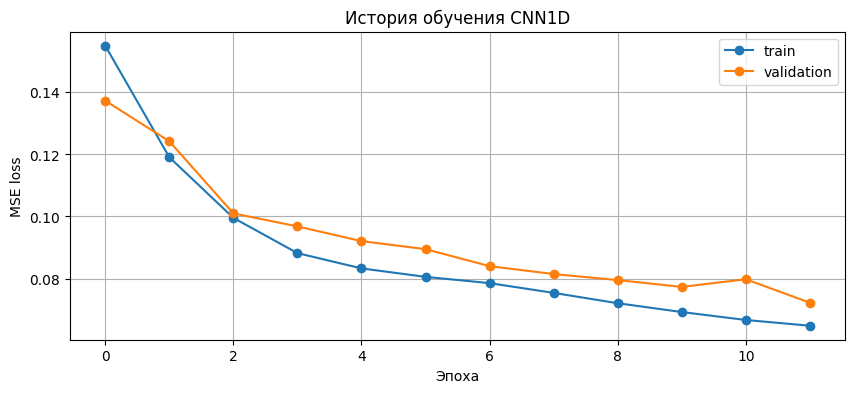

Время обучения CNN1D: 24.6 секунд


In [24]:
EPOCHS = 12 if FAST_MODE else 25

cnn_model, cnn_history, cnn_seconds = train_neural_network(
    cnn_model, train_loader, val_loader, epochs=EPOCHS
)
plot_history(cnn_history, "История обучения CNN1D")
test_target_times = hourly.index[test_indices + HORIZON]
cnn_pred_series = pd.Series(
    predict_neural_network(cnn_model, test_loader),
    index=test_target_times,
    name="CNN1D"
)
print(f"Время обучения CNN1D: {cnn_seconds:.1f} секунд")

Эпоха 01: train_loss=0.09998, val_loss=0.06095
Эпоха 02: train_loss=0.06196, val_loss=0.06009
Эпоха 03: train_loss=0.06008, val_loss=0.05932
Эпоха 04: train_loss=0.05961, val_loss=0.05822
Эпоха 05: train_loss=0.05893, val_loss=0.05830
Эпоха 06: train_loss=0.05795, val_loss=0.05847
Эпоха 07: train_loss=0.05717, val_loss=0.05901
Early stopping.


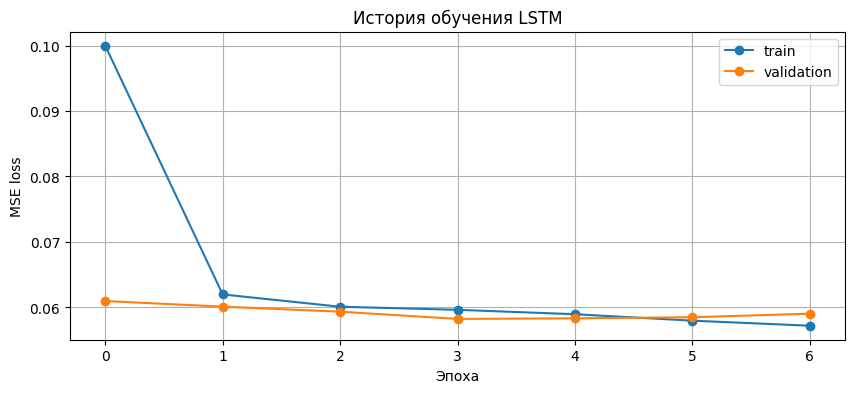

Время обучения LSTM: 16.1 секунд


In [25]:
lstm_model, lstm_history, lstm_seconds = train_neural_network(
    lstm_model, train_loader, val_loader, epochs=EPOCHS
)
plot_history(lstm_history, "История обучения LSTM")
lstm_pred_series = pd.Series(
    predict_neural_network(lstm_model, test_loader),
    index=test_target_times,
    name="LSTM"
)
print(f"Время обучения LSTM: {lstm_seconds:.1f} секунд")

## 16. Метрики и сравнение моделей

Используются три метрики:

- **MAE** — средняя абсолютная ошибка в градусах; меньше — лучше.
- **RMSE** — сильнее штрафует крупные промахи; меньше — лучше.
- **R²** — доля объяснённой изменчивости; ближе к 1 — лучше.

`MAPE` не используется, поскольку температура может быть отрицательной либо близкой к нулю, что делает процентную ошибку плохо интерпретируемой.

In [26]:
actual_temperature = hourly[TARGET].rename("Actual")
predictions_table = pd.concat(
    [actual_temperature, rf_pred_series, cnn_pred_series, lstm_pred_series],
    axis=1
).dropna()

def regression_metrics(y_true, y_pred):
    return {
        "MAE, °C": mean_absolute_error(y_true, y_pred),
        "RMSE, °C": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R²": r2_score(y_true, y_pred),
    }

metrics_table = pd.DataFrame({
    name: regression_metrics(predictions_table["Actual"], predictions_table[name])
    for name in ["Random Forest", "CNN1D", "LSTM"]
}).T.sort_values("RMSE, °C")

display(
    metrics_table.style.format("{:.4f}")
    .highlight_min(subset=["MAE, °C", "RMSE, °C"], color="lightgreen")
    .highlight_max(subset=["R²"], color="lightgreen")
)
print("Общих тестовых наблюдений:", len(predictions_table))

,"MAE, °C","RMSE, °C",R²
LSTM,2.2643,2.9273,0.8693
Random Forest,2.2992,2.9755,0.8649
CNN1D,2.6114,3.3162,0.8323


Общих тестовых наблюдений: 26298


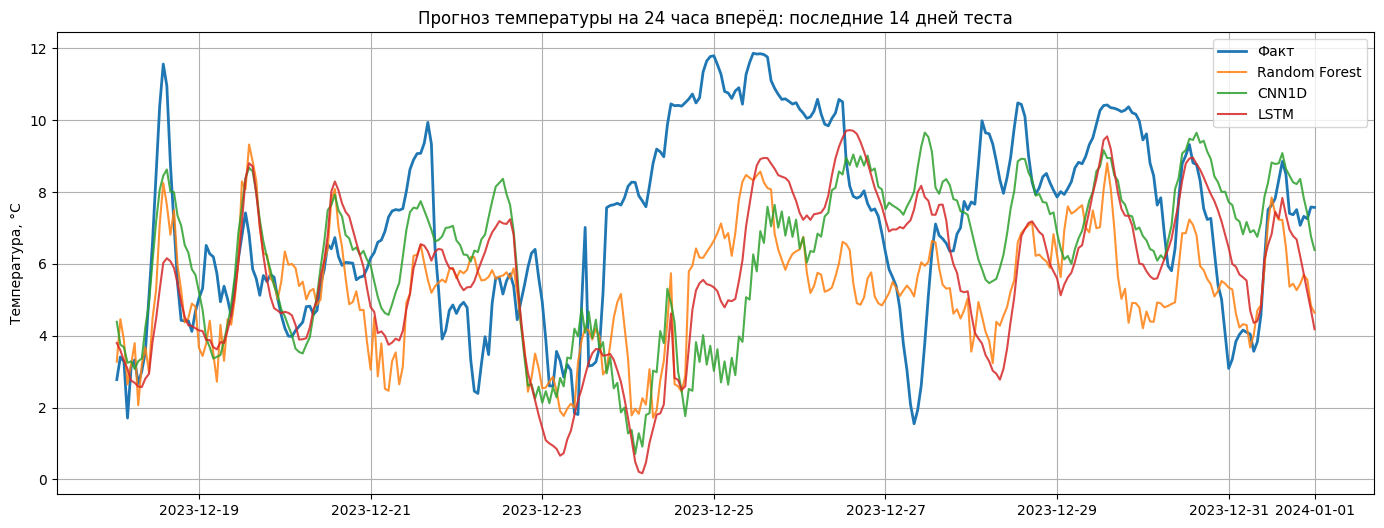

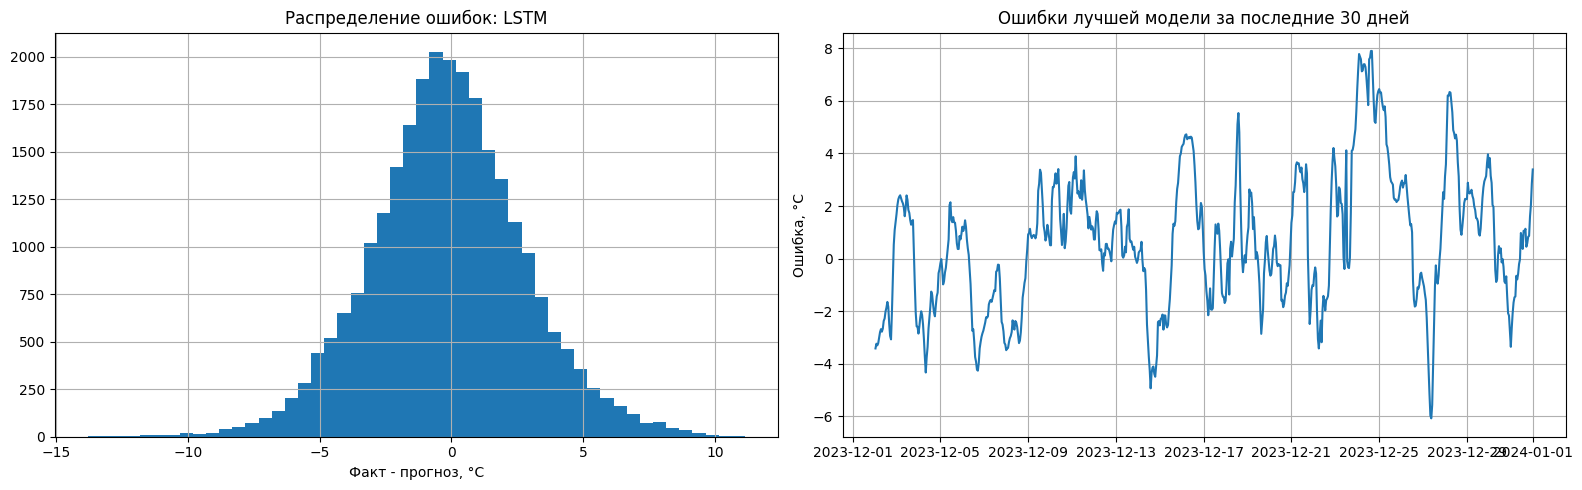

In [27]:
plot_part = predictions_table.iloc[-24 * 14:]
plt.figure(figsize=(17, 6))
plt.plot(plot_part.index, plot_part["Actual"], label="Факт", linewidth=2)
plt.plot(plot_part.index, plot_part["Random Forest"], label="Random Forest", alpha=0.85)
plt.plot(plot_part.index, plot_part["CNN1D"], label="CNN1D", alpha=0.85)
plt.plot(plot_part.index, plot_part["LSTM"], label="LSTM", alpha=0.85)
plt.title("Прогноз температуры на 24 часа вперёд: последние 14 дней теста")
plt.ylabel("Температура, °C")
plt.legend()
plt.show()

best_name = metrics_table.index[0]
errors = predictions_table["Actual"] - predictions_table[best_name]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].hist(errors, bins=50)
axes[0].set_title(f"Распределение ошибок: {best_name}")
axes[0].set_xlabel("Факт - прогноз, °C")
axes[1].plot(errors.iloc[-24 * 30:])
axes[1].set_title(f"Ошибки лучшей модели за последние 30 дней")
axes[1].set_ylabel("Ошибка, °C")
plt.tight_layout()
plt.show()

## 17. Автоматический итоговый вывод

Следующая ячейка формирует итог на основе фактических результатов вашего запуска. Полученный текст можно перенести в отчёт.

In [29]:
best_model = metrics_table.index[0]
best_mae = metrics_table.loc[best_model, "MAE, °C"]
best_rmse = metrics_table.loc[best_model, "RMSE, °C"]
best_r2 = metrics_table.loc[best_model, "R²"]

print("вывод")
print(
    f"Лучшей по RMSE моделью является {best_model}: "
    f"MAE={best_mae:.3f} °C, RMSE={best_rmse:.3f} °C, R²={best_r2:.3f}."
)
print("Причина преимущества: LSTM хорошо учитывает последовательные зависимости в 72-часовом окне.")
print("Различия моделей связаны с представлением времени: ручные признаки, локальные свёртки или рекуррентная память.")

вывод
Лучшей по RMSE моделью является LSTM: MAE=2.264 °C, RMSE=2.927 °C, R²=0.869.
Причина преимущества: LSTM хорошо учитывает последовательные зависимости в 72-часовом окне.
Различия моделей связаны с представлением времени: ручные признаки, локальные свёртки или рекуррентная память.


Также близкое значение к LSTM показал случайный лес, у нах разница в 1.6%

## 18. Краткие ответы для защиты

**Почему это многомерный временной ряд?**  
В каждый момент времени имеются сразу несколько изменяющихся признаков: температура, давление, влажность, ветер, осадки и радиация.

**Почему решается регрессия?**  
Цель `T (degC)` является непрерывным числом.

**Почему горизонт прогноза равен 24 часам?**  
Суточный прогноз практически интерпретируем и соответствует выраженной суточной сезонности температуры.

**Почему сделана часовая агрегация?**  
Исходный шаг 10 минут создаёт более миллиона строк; для прогноза на сутки часового разрешения достаточно, а обучение заметно ускоряется.

**Почему train/test нельзя перемешивать?**  
Модель не должна обучаться на будущем и затем прогнозировать прошлое.

**Какие три метода feature extraction использованы?**  
Lag features, rolling statistics и FFT features.

**Зачем RobustScaler?**  
Метеорологические признаки имеют разные шкалы и возможные экстремумы; устойчивое масштабирование облегчает обучение нейросетей.

**Почему не применяется MAPE?**  
Температура бывает отрицательной и близкой к нулю, поэтому процентные ошибки становятся некорректными.

**Чем различаются модели?**  
Random Forest использует вручную заданные временные признаки; CNN1D извлекает локальные паттерны; LSTM моделирует последовательность с помощью памяти.